PREMIER LEAGUE WINNER PREDICTOR 
MACHINE LEARNING PROJECT
GROUP L 2026

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [3]:
df = pd.read_csv("Data.csv")

In [4]:
df.head()

,Home_team_score,Home_team_name,Away_team_score,Away_team_name,attendance,referee,stadium,Season,Date
0,2,West Ham United,2,Arsenal,NaN,David Coote,"London Stadium, London",2022/23,"Sun 16 Apr 2023, 14:00 BST"
1,2,Tottenham Hotspur,3,Bournemouth,"Att: 61,369",Andy Madley,"Tottenham Hotspur Stadium, London",2022/23,"Sat 15 Apr 2023, 15:15 BST"
2,0,Southampton,2,Crystal Palace,"Att: 30,309",Michael Oliver,"St. Mary's Stadium, Southampton",2022/23,"Sat 15 Apr 2023, 15:00 BST"
3,0,Nottingham Forest,2,Manchester United,"Att: 29,435",Simon Hooper,"The City Ground, Nottingham",2022/23,"Sun 16 Apr 2023, 16:30 BST"
4,3,Manchester City,1,Leicester City,"Att: 53,329",Darren England,"Etihad Stadium, Manchester",2022/23,"Sat 15 Apr 2023, 17:30 BST"


CHECK COLUMN NAMES 

In [5]:
print(df.columns.tolist())

['Home_team_score', 'Home_team_name', 'Away_team_score', 'Away_team_name', 'attendance', 'referee', 'stadium', 'Season', 'Date']


CLEANING COLUMN NAMES

In [7]:
df.columns = df.columns.str.strip().str.lower()

In [8]:
print(df.columns.tolist())

['home_team_score', 'home_team_name', 'away_team_score', 'away_team_name', 'attendance', 'referee', 'stadium', 'season', 'date']


RENAMING KEY COLUMN NAMES

In [14]:
df = df.rename(columns={
    "home_team_name": "home_team",
    "away_team_name": "away_team",
    "home_team_score": "home_goals",
    "away_team_score": "away_goals"
})

In [15]:
print(df.columns.tolist())

['home_goals', 'home_team', 'away_goals', 'away_team', 'attendance', 'referee', 'stadium', 'season', 'date']


In [16]:
df[["home_team", "away_team", "home_goals", "away_goals", "season", "date"]].head()

,home_team,away_team,home_goals,away_goals,season,date
0,West Ham United,Arsenal,2,2,2022/23,"Sun 16 Apr 2023, 14:00 BST"
1,Tottenham Hotspur,Bournemouth,2,3,2022/23,"Sat 15 Apr 2023, 15:15 BST"
2,Southampton,Crystal Palace,0,2,2022/23,"Sat 15 Apr 2023, 15:00 BST"
3,Nottingham Forest,Manchester United,0,2,2022/23,"Sun 16 Apr 2023, 16:30 BST"
4,Manchester City,Leicester City,3,1,2022/23,"Sat 15 Apr 2023, 17:30 BST"


CHECKING TEAM NAMES 

In [17]:
print(sorted(df["home_team"].dropna().unique()))

['1. FC Kaiserslautern', '1. FC Köln', '1. FC Köln U19', '1. FC Nürnberg', '1. FC Union Berlin', '1. FSV Mainz 05', 'A-League All Stars', 'AC Bellinzona', 'AD Ceuta', 'AD San Juan', 'AD Unión Adarve', 'ADO Den Haag', 'AEK Athens', 'AEK Athens U19', 'AEK Larnaka', 'AEL Limassol U19', 'AEM', 'AF Virois', 'AFC Bournemouth', 'AFC Dunstable Ladies', 'AFC St Austell Ladies', 'AFC Stoneham Ladies', 'AFC Sudbury', 'AFC Telford United Ladies', 'AFC Wimbledon', 'AFC Wimbledon Ladies', 'AFC Wimbledon U18', 'AG Caennaise', 'AL Déville Maromme', 'APOEL Nicosia', 'APOEL U19', 'AS Ifs', 'AS Trouville Deauville', 'ASU Politehnica Timisoara', 'ASV Altenlingen III', 'AZ', 'AZ U19', 'Aalborg BK', 'Aberdeen', 'Abingdon Town Women', 'Abingdon United Women', 'Accrington Stanley', 'Accrington Stanley U18', 'Acle United Ladies', 'Actonians LFC', 'Adana Demirspor', 'Adelaide United', 'Airdrieonians', 'Ajax', 'Ajax U19', 'Ajax Women', 'Akademia e Futbollit U19', 'Akhisarspor', 'Al Ahly', 'Al Ain', 'Al Duhail', 

FILTERING EPL TEAMS

In [18]:
epl_teams = [
    "Arsenal",
    "Aston Villa",
    "Bournemouth",
    "Brentford",
    "Brighton",
    "Burnley",
    "Cardiff City",
    "Chelsea",
    "Crystal Palace",
    "Everton",
    "Fulham",
    "Huddersfield Town",
    "Hull City",
    "Leeds United",
    "Leicester City",
    "Liverpool",
    "Luton Town",
    "Manchester City",
    "Manchester United",
    "Middlesbrough",
    "Newcastle United",
    "Norwich City",
    "Nottingham Forest",
    "Queens Park Rangers",
    "Reading",
    "Sheffield United",
    "Southampton",
    "Stoke City",
    "Sunderland",
    "Swansea City",
    "Tottenham Hotspur",
    "Watford",
    "West Bromwich Albion",
    "West Ham United",
    "Wigan Athletic",
    "Wolverhampton Wanderers",
    "Blackburn Rovers",
    "Blackpool",
    "Bolton Wanderers",
    "Birmingham City",
    "Charlton Athletic",
    "Derby County",
    "Ipswich Town",
    "Coventry City",
    "Portsmouth"
]

In [19]:
df = df[
    df["home_team"].isin(epl_teams) &
    df["away_team"].isin(epl_teams)
].copy()

In [20]:
print(df.shape)

(5947, 9)


VIEW FILTERED DATA

In [21]:
df[["home_team", "away_team", "home_goals", "away_goals", "season"]].head()

,home_team,away_team,home_goals,away_goals,season
0,West Ham United,Arsenal,2,2,2022/23
1,Tottenham Hotspur,Bournemouth,2,3,2022/23
2,Southampton,Crystal Palace,0,2,2022/23
3,Nottingham Forest,Manchester United,0,2,2022/23
4,Manchester City,Leicester City,3,1,2022/23


CHECKING DATA TYPES

In [22]:
print(df.dtypes)

home_goals    object
home_team     object
away_goals    object
away_team     object
attendance    object
referee       object
stadium       object
season        object
date          object
dtype: object


CONVERT GOALS TO NUMERIC

In [23]:
df["home_goals"] = pd.to_numeric(df["home_goals"], errors="coerce")
df["away_goals"] = pd.to_numeric(df["away_goals"], errors="coerce")

CONVERT DATE TO NUMERIC

In [24]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")


C:\Users\ELITEX21012G2\AppData\Local\Temp\ipykernel_15752\930674051.py:1: FutureWarning: Parsed string "Sun 16 Apr 2023, 14:00 BST" included an un-recognized timezone "BST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")


HANDLING MISSING VALUES

In [25]:
print(df[["season", "home_team", "away_team", "home_goals", "away_goals", "date"]].isnull().sum())

season           0
home_team        0
away_team        0
home_goals       0
away_goals       0
date          3194
dtype: int64


DROP THE ROWS MISSING VALUES

In [26]:
df = df.dropna(subset=["season", "home_team", "away_team", "home_goals", "away_goals"])

CONFIRM CLEANED DATA

In [27]:
df[["season", "date", "home_team", "away_team", "home_goals", "away_goals"]].head()

,season,date,home_team,away_team,home_goals,away_goals
0,2022/23,2023-04-16 14:00:00,West Ham United,Arsenal,2,2
1,2022/23,2023-04-15 15:15:00,Tottenham Hotspur,Bournemouth,2,3
2,2022/23,2023-04-15 15:00:00,Southampton,Crystal Palace,0,2
3,2022/23,2023-04-16 16:30:00,Nottingham Forest,Manchester United,0,2
4,2022/23,2023-04-15 17:30:00,Manchester City,Leicester City,3,1


CHECKING DATA TYPES

In [28]:
print(df.dtypes)

home_goals             int64
home_team             object
away_goals             int64
away_team             object
attendance            object
referee               object
stadium               object
season                object
date          datetime64[ns]
dtype: object


CREATING AND CHECKING MATCH RESULTS

In [30]:
df["result"] = np.where(
    df["home_goals"] > df["away_goals"], "H",
    np.where(df["home_goals"] < df["away_goals"], "A", "D")
)

In [31]:
df[["home_team", "away_team", "home_goals", "away_goals", "result"]].head()

,home_team,away_team,home_goals,away_goals,result
0,West Ham United,Arsenal,2,2,D
1,Tottenham Hotspur,Bournemouth,2,3,A
2,Southampton,Crystal Palace,0,2,A
3,Nottingham Forest,Manchester United,0,2,A
4,Manchester City,Leicester City,3,1,H


CREATE HOME RESULTS 

In [33]:
df["home_points"] = np.where(df["result"] == "H", 3, np.where(df["result"] == "D", 1, 0))

CREATE AWAY POINTS

In [34]:
df["away_points"] = np.where(df["result"] == "A", 3, np.where(df["result"] == "D", 1, 0))

CREATE HOME AND WIN COLUMN

In [35]:
df["home_win"] = (df["result"] == "H").astype(int)

CREATE AWAY WIN COLUMN

In [37]:
df["away_win"] = (df["result"] == "A").astype(int)

CREATE DRAW COLUMN

In [38]:
df["draw"] = (df["result"] == "D").astype(int)

CREATING HOME LOSS COLUMN

In [39]:
df["home_loss"] = (df["result"] == "A").astype(int)

CREATING AWAY LOSS COLUMN

In [40]:
df["away_loss"] = (df["result"] == "H").astype(int)

In [41]:
df[[
    "home_team",
    "away_team",
    "home_goals",
    "away_goals",
    "result",
    "home_points",
    "away_points",
    "home_win",
    "away_win",
    "draw",
    "home_loss",
    "away_loss"
]].head()

,home_team,away_team,home_goals,away_goals,result,home_points,away_points,home_win,away_win,draw,home_loss,away_loss
0,West Ham United,Arsenal,2,2,D,1,1,0,0,1,0,0
1,Tottenham Hotspur,Bournemouth,2,3,A,0,3,0,1,0,1,0
2,Southampton,Crystal Palace,0,2,A,0,3,0,1,0,1,0
3,Nottingham Forest,Manchester United,0,2,A,0,3,0,1,0,1,0
4,Manchester City,Leicester City,3,1,H,3,0,1,0,0,0,1


HOME TEAM SEASON SUMMARY

In [42]:
home_stats = df.groupby(["season", "home_team"]).agg(
    home_matches=("home_team", "count"),
    home_points=("home_points", "sum"),
    home_wins=("home_win", "sum"),
    home_draws=("draw", "sum"),
    home_losses=("home_loss", "sum"),
    home_gf=("home_goals", "sum"),
    home_ga=("away_goals", "sum")
).reset_index()

RENAMING HOME TEAM COLUMN TO TEAM 

In [43]:
home_stats = home_stats.rename(columns={"home_team": "team"})

VIEW HOME STATS

In [44]:
home_stats.head()

,season,team,home_matches,home_points,home_wins,home_draws,home_losses,home_gf,home_ga
0,2004/05,Chelsea,1,1,0,1,0,0,0
1,2004/05,Liverpool,1,3,1,0,0,1,0
2,2006/07,Chelsea,1,3,1,0,0,1,0
3,2006/07,Liverpool,1,3,1,0,0,1,0
4,2008/09,Arsenal,1,0,0,0,1,1,3


AWAY TEAM SEASON SUMMARY

In [45]:
away_stats = df.groupby(["season", "away_team"]).agg(
    away_matches=("away_team", "count"),
    away_points=("away_points", "sum"),
    away_wins=("away_win", "sum"),
    away_draws=("draw", "sum"),
    away_losses=("away_loss", "sum"),
    away_gf=("away_goals", "sum"),
    away_ga=("home_goals", "sum")
).reset_index()

RENAME AWAY TEAM TO TEAM

In [46]:
away_stats = away_stats.rename(columns={"away_team": "team"})

VIEW AWAY STATS

In [47]:
away_stats.head()

,season,team,away_matches,away_points,away_wins,away_draws,away_losses,away_gf,away_ga
0,2004/05,Chelsea,1,0,0,0,1,0,1
1,2004/05,Liverpool,1,1,0,1,0,0,0
2,2006/07,Chelsea,1,0,0,0,1,0,1
3,2006/07,Liverpool,1,0,0,0,1,0,1
4,2008/09,Arsenal,1,0,0,0,1,0,1


MERGE HOME AND AWAY TABLES

In [48]:
team_season = pd.merge(
    home_stats,
    away_stats,
    on=["season", "team"],
    how="outer"
)

FILLING MISSING VALUES

In [49]:
team_season = team_season.fillna(0)

VIEW MERGED TABLE 

In [50]:
team_season.head()

,season,team,home_matches,home_points,home_wins,home_draws,home_losses,home_gf,home_ga,away_matches,away_points,away_wins,away_draws,away_losses,away_gf,away_ga
0,2004/05,Chelsea,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,2004/05,Liverpool,1.0,3.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
2,2006/07,Chelsea,1.0,3.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,2006/07,Liverpool,1.0,3.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,2008/09,Arsenal,1.0,0.0,0.0,0.0,1.0,1.0,3.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


CREATING TOTAL MATCHES

In [51]:
team_season["matches"] = team_season["home_matches"] + team_season["away_matches"]

CEATE TOTAL POINTS

In [52]:
team_season["points"] = team_season["home_points"] + team_season["away_points"]

CREATE TOTAL WINS

In [53]:
team_season["wins"] = team_season["home_wins"] + team_season["away_wins"]

CREATE TOTAL DRAWS

In [54]:
team_season["draws"] = team_season["home_draws"] + team_season["away_draws"]

CREATE TOTAL LOSSES

In [55]:
team_season["losses"] = team_season["home_losses"] + team_season["away_losses"]

CREATE GOALS FOR

In [60]:
team_season["gf"] = team_season["home_gf"] + team_season["away_gf"]

CREATE GOALS AGAINST

In [61]:
team_season["ga"] = team_season["home_ga"] + team_season["away_ga"]

CREATE GOAL DIFFERENCE

In [62]:
team_season["gd"] = team_season["gf"] - team_season["ga"]

FINISHED SEASON TOTALS

In [63]:
team_season[[
    "season",
    "team",
    "matches",
    "points",
    "wins",
    "draws",
    "losses",
    "gf",
    "ga",
    "gd"
]].head()

,season,team,matches,points,wins,draws,losses,gf,ga,gd
0,2004/05,Chelsea,2.0,1.0,0.0,1.0,1.0,0.0,1.0,-1.0
1,2004/05,Liverpool,2.0,4.0,1.0,1.0,0.0,1.0,0.0,1.0
2,2006/07,Chelsea,2.0,3.0,1.0,0.0,1.0,1.0,1.0,0.0
3,2006/07,Liverpool,2.0,3.0,1.0,0.0,1.0,1.0,1.0,0.0
4,2008/09,Arsenal,2.0,0.0,0.0,0.0,2.0,1.0,4.0,-3.0


POINTS PER GAME

In [64]:
team_season["ppg"] = team_season["points"] / team_season["matches"]

WIN RATIO

In [79]:
team_season["win_ratio"] = team_season["wins"] / team_season["matches"]

DRAW RATIO

In [67]:
team_season["draw_ratio"] = team_season["draws"] / team_season["matches"]

LOSS RATIO

In [68]:
team_season["loss_ratio"] = team_season["losses"] / team_season["matches"]

GOAL DIFFERENCE

In [69]:
team_season["gd_per_match"] = team_season["gd"] / team_season["matches"]

GOALS FOR PER MATCH

In [70]:
team_season["gf_per_match"] = team_season["gf"] / team_season["matches"]

GOALS AGAINST PER MATCH

In [71]:
team_season["ga_per_match"] = team_season["ga"] / team_season["matches"]

HOME GOAL DIFFERENCE

In [72]:
team_season["home_gd"] = team_season["home_gf"] - team_season["home_ga"]

AWAY GOAL DIFFERENCE

In [73]:
team_season["away_gd"] = team_season["away_gf"] - team_season["away_ga"]

HOME WIN RATIO

In [74]:
team_season["home_win_ratio"] = team_season["home_wins"] / team_season["home_matches"]

AWAY WIN RATIO

In [76]:
team_season["away_win_ratio"] = team_season["away_wins"] / team_season["away_matches"]

CLEANING OF INFINITES AND MISSING VALUES

In [77]:
team_season = team_season.replace([np.inf, -np.inf], np.nan)
team_season = team_season.fillna(0)

ENGINEERED FEATURES

In [80]:
team_season[[
    "season",
    "team",
    "points",
    "gd",
    "ppg",
    "win_ratio",
    "gd_per_match",
    "home_win_ratio",
    "away_win_ratio"
]].head()

,season,team,points,gd,ppg,win_ratio,gd_per_match,home_win_ratio,away_win_ratio
0,2004/05,Chelsea,1.0,-1.0,0.5,0.0,-0.5,0.0,0.0
1,2004/05,Liverpool,4.0,1.0,2.0,0.5,0.5,1.0,0.0
2,2006/07,Chelsea,3.0,0.0,1.5,0.5,0.0,1.0,0.0
3,2006/07,Liverpool,3.0,0.0,1.5,0.5,0.0,1.0,0.0
4,2008/09,Arsenal,0.0,-3.0,0.0,0.0,-1.5,0.0,0.0


SORTING TEAMS WITHIN EACH SEASON

In [81]:
team_season = team_season.sort_values(
    by=["season", "points", "gd", "gf"],
    ascending=[True, False, False, False]
)

CREATE CHAMPION COLUMN

In [82]:
team_season["champion"] = 0

MARK TOP TEAM IN EACH SEASON AS A CHAMPION

In [83]:
team_season.loc[
    team_season.groupby("season").head(1).index,
    "champion"
] = 1

VIEW CHAMPIONS

In [84]:
team_season[team_season["champion"] == 1][["season", "team", "points", "gd", "gf"]]

,season,team,points,gd,gf
1,2004/05,Liverpool,4.0,1.0,1.0
2,2006/07,Chelsea,3.0,0.0,1.0
7,2008/09,Manchester United,6.0,3.0,4.0
22,2014/15,Norwich City,77.0,33.0,76.0
32,2015/16,Reading,3.0,2.0,3.0
35,2016/17,Nottingham Forest,3.0,2.0,4.0
54,2017/18,Wolverhampton Wanderers,73.0,32.0,60.0
79,2018/19,Manchester City,132.0,77.0,144.0
121,2019/20,Liverpool,133.0,57.0,130.0
165,2020/21,Manchester City,142.0,91.0,150.0


DEFINE FEATURE COLUMNS

In [85]:
feature_cols = [
    "matches",
    "points",
    "wins",
    "draws",
    "losses",
    "gf",
    "ga",
    "gd",
    "ppg",
    "win_ratio",
    "draw_ratio",
    "loss_ratio",
    "gd_per_match",
    "gf_per_match",
    "ga_per_match",
    "home_points",
    "away_points",
    "home_gd",
    "away_gd",
    "home_win_ratio",
    "away_win_ratio"
]

CREATE X

In [86]:
X = team_season[feature_cols]

CREATE Y

In [87]:
y = team_season["champion"]

CHECK SHAPES

In [88]:
print(X.shape)
print(y.shape)

(347, 21)
(347,)


SPLIT TRAINING AND TESTING DATA

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

CHECK SPLIT SIZES

In [90]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(277, 21)
(70, 21)
(277,)
(70,)


CREATING A LOGISTIC REGRESSION MODEL

In [93]:
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=2000))
])

TRAIN LOGISTIC MODEL

In [94]:
log_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

PREDICT WITH LOGISTIC REGRESSION

In [96]:
log_preds = log_model.predict(X_test)

PREDICT PROBABILITIES WITH LOGISTIC REGRESSION

In [97]:
log_probs = log_model.predict_proba(X_test)[:, 1]

CLASSIFICATION REPORT FOR LOGISTIC REGRESSION

In [98]:
print(classification_report(y_test, log_preds))

              precision    recall  f1-score   support

           0       0.98      0.81      0.89        64
           1       0.29      0.83      0.43         6

    accuracy                           0.81        70
   macro avg       0.64      0.82      0.66        70
weighted avg       0.92      0.81      0.85        70



CONFUSION MATRIX FOR LOGISTIC REGRESSION

In [99]:
print(confusion_matrix(y_test, log_preds))

[[52 12]
 [ 1  5]]


ROC-AUC FOR LOGISTIC REGRESSION

In [100]:
print(roc_auc_score(y_test, log_probs))

0.9322916666666666


CREATING RANDOM FOREST MODEL

In [101]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

TRAINING RANDOM FOREST MODEL

In [102]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=300,
                       random_state=42)

PREDICT WITH RANDOM FOREST

In [103]:
rf_preds = rf_model.predict(X_test)

PREDICT PROBABILITIES WITH RANDOM FOREST

In [104]:
rf_probs = rf_model.predict_proba(X_test)[:, 1]

In [105]:
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93        64
           1       0.36      0.67      0.47         6

    accuracy                           0.87        70
   macro avg       0.66      0.78      0.70        70
weighted avg       0.91      0.87      0.89        70



CONFUSION MATRIX FOR RANDOM FOREST

In [106]:
print(confusion_matrix(y_test, rf_preds))

[[57  7]
 [ 2  4]]


ROC-AUC FOR RANDOM FOREST

In [107]:
print(roc_auc_score(y_test, rf_probs))

0.8984375


CREATE GRADIENT BOOSTING MODEL

In [108]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

TRAIN GRADIENT BOOSTING


In [109]:
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

PREDICT WITH GRADIENT BOOSTING

In [111]:
gb_preds = gb_model.predict(X_test)

PREDICT PROBABILITIES WITH GRADIENT BOOSTING

In [112]:
gb_probs = gb_model.predict_proba(X_test)[:, 1]

CLASSIFICATION REPORT FOR GRADIENT BOOSTING

In [113]:
print(classification_report(y_test, gb_preds))

              precision    recall  f1-score   support

           0       0.97      0.88      0.92        64
           1       0.33      0.67      0.44         6

    accuracy                           0.86        70
   macro avg       0.65      0.77      0.68        70
weighted avg       0.91      0.86      0.88        70



CONFUSION MATRIX FOR GRADIENT BOOSTING

In [114]:
print(confusion_matrix(y_test, gb_preds))

[[56  8]
 [ 2  4]]


ROC-AUC FOR GRADIENT BOOSTING

In [115]:
print(roc_auc_score(y_test, gb_probs))

0.9010416666666666


TRAIN GRADIENT BOOSTING ON ALL DATA

In [116]:
gb_model.fit(X, y)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

CREATE CHAMPION PROBABILITY COLUMN

In [117]:
team_season["champion_probability"] = gb_model.predict_proba(X)[:, 1]

GET TO PREDICTED TEAM PER SEASON

In [118]:
season_predictions = team_season.sort_values(
    by=["season", "champion_probability"],
    ascending=[True, False]
).groupby("season").head(1)

VIEW PREDICTED CHAMPIONS

In [119]:
season_predictions[["season", "team", "champion_probability", "points", "gd"]]

,season,team,champion_probability,points,gd
1,2004/05,Liverpool,0.920037,4.0,1.0
2,2006/07,Chelsea,0.478035,3.0,0.0
7,2008/09,Manchester United,0.990797,6.0,3.0
22,2014/15,Norwich City,0.914570,77.0,33.0
32,2015/16,Reading,0.981062,3.0,2.0
35,2016/17,Nottingham Forest,0.976449,3.0,2.0
54,2017/18,Wolverhampton Wanderers,0.986791,73.0,32.0
79,2018/19,Manchester City,0.974670,132.0,77.0
121,2019/20,Liverpool,0.983059,133.0,57.0
165,2020/21,Manchester City,0.980760,142.0,91.0


SAVE TEAM SEASON DATASET

In [120]:
team_season.to_csv("team_season_features.csv", index=False)

SAVE PREDICTED CHAMPIONS

TRAIN FINAL MODEL DATA

In [123]:
gb_model.fit(X, y)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

CHAMPION PROBABILITIES

In [125]:
team_season["champion_probability"] = gb_model.predict_proba(X)[:, 1]

PREDICTION LEADERBOARD

In [126]:
prediction_leaderboard = team_season.sort_values(
    by="champion_probability",
    ascending=False
)

 VIEW TOP PREDICTIONS

In [127]:
prediction_leaderboard[[
    "season",
    "team",
    "champion_probability",
    "points",
    "gd"
]].head(10)

,season,team,champion_probability,points,gd
342,Premier League Asia Trophy Season 2019/2020,Wolverhampton Wanderers,0.996823,4.0,4.0
344,UEFA Champions League Season 2003/2004,Chelsea,0.993142,4.0,1.0
209,2021/22,Manchester City,0.992881,143.0,106.0
334,Friendly Season 2022/2023,Manchester United,0.991742,7.0,6.0
330,English League Cup Season 2007/2008,Tottenham Hotspur,0.991554,7.0,5.0
7,2008/09,Manchester United,0.990797,6.0,3.0
54,2017/18,Wolverhampton Wanderers,0.986791,73.0,32.0
290,English Football League - League One Season 20...,Wolverhampton Wanderers,0.986342,12.0,7.0
121,2019/20,Liverpool,0.983059,133.0,57.0
32,2015/16,Reading,0.981062,3.0,2.0


CONVERT PROBABILITIES TO PERCENTAGES

In [128]:
prediction_leaderboard["champion_probability"] = (
    prediction_leaderboard["champion_probability"] * 100
).round(2)

DISPLAY LEADERBOARD 

In [129]:
prediction_leaderboard[[
    "team",
    "season",
    "champion_probability",
    "points",
    "gd"
]].head(10)

,team,season,champion_probability,points,gd
342,Wolverhampton Wanderers,Premier League Asia Trophy Season 2019/2020,99.68,4.0,4.0
344,Chelsea,UEFA Champions League Season 2003/2004,99.31,4.0,1.0
209,Manchester City,2021/22,99.29,143.0,106.0
334,Manchester United,Friendly Season 2022/2023,99.17,7.0,6.0
330,Tottenham Hotspur,English League Cup Season 2007/2008,99.16,7.0,5.0
7,Manchester United,2008/09,99.08,6.0,3.0
54,Wolverhampton Wanderers,2017/18,98.68,73.0,32.0
290,Wolverhampton Wanderers,English Football League - League One Season 20...,98.63,12.0,7.0
121,Liverpool,2019/20,98.31,133.0,57.0
32,Reading,2015/16,98.11,3.0,2.0


CLEAN PRESENTATION LEADERBOARD

In [130]:
top_predictions = prediction_leaderboard[[
    "team",
    "champion_probability"
]].head(10)

top_predictions

,team,champion_probability
342,Wolverhampton Wanderers,99.68
344,Chelsea,99.31
209,Manchester City,99.29
334,Manchester United,99.17
330,Tottenham Hotspur,99.16
7,Manchester United,99.08
54,Wolverhampton Wanderers,98.68
290,Wolverhampton Wanderers,98.63
121,Liverpool,98.31
32,Reading,98.11


SAVE RESULTS

In [131]:
prediction_leaderboard.to_csv("champion_prediction_leaderboard.csv", index=False)

SAVE TEAM SEASON DATASET

In [132]:
team_season.to_csv("team_season_features.csv", index=False)

In [133]:
print("Premier League Champion Prediction Leaderboard")
print("-----------------------------------------------")

for index, row in top_predictions.iterrows():
    print(f"{row['team']} : {row['champion_probability']}%")

Premier League Champion Prediction Leaderboard
-----------------------------------------------
Wolverhampton Wanderers : 99.68%
Chelsea : 99.31%
Manchester City : 99.29%
Manchester United : 99.17%
Tottenham Hotspur : 99.16%
Manchester United : 99.08%
Wolverhampton Wanderers : 98.68%
Wolverhampton Wanderers : 98.63%
Liverpool : 98.31%
Reading : 98.11%


In [134]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

HISTOGRAM OF POINTS

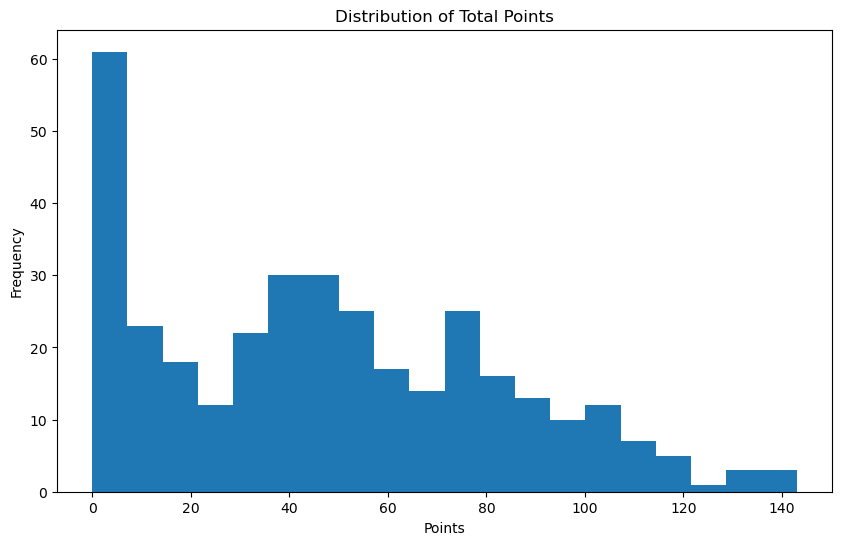

In [135]:
plt.figure(figsize=(10, 6))
plt.hist(team_season["points"], bins=20)
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.title("Distribution of Total Points")
plt.show()

HISTOGRAM OF GOAL DIFFERENCES

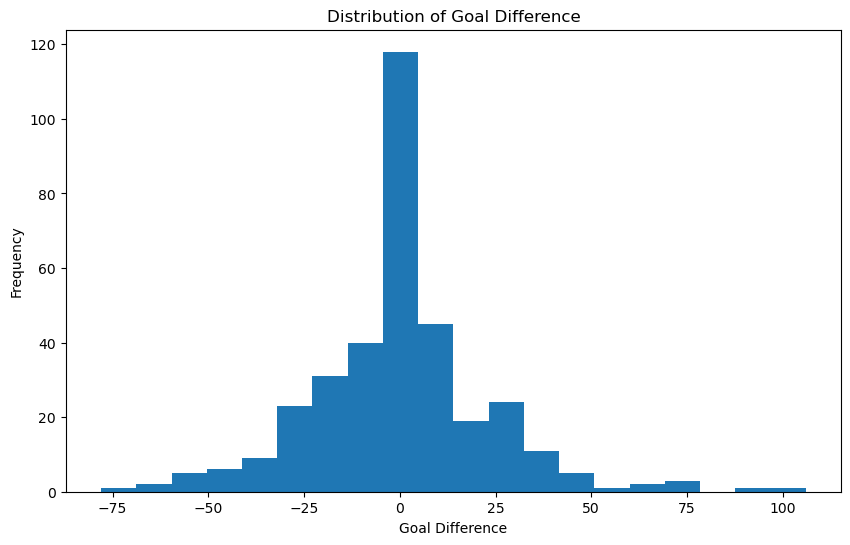

In [136]:
plt.figure(figsize=(10, 6))
plt.hist(team_season["gd"], bins=20)
plt.xlabel("Goal Difference")
plt.ylabel("Frequency")
plt.title("Distribution of Goal Difference")
plt.show()

HISTOGRAM OF POINTS PER GAME

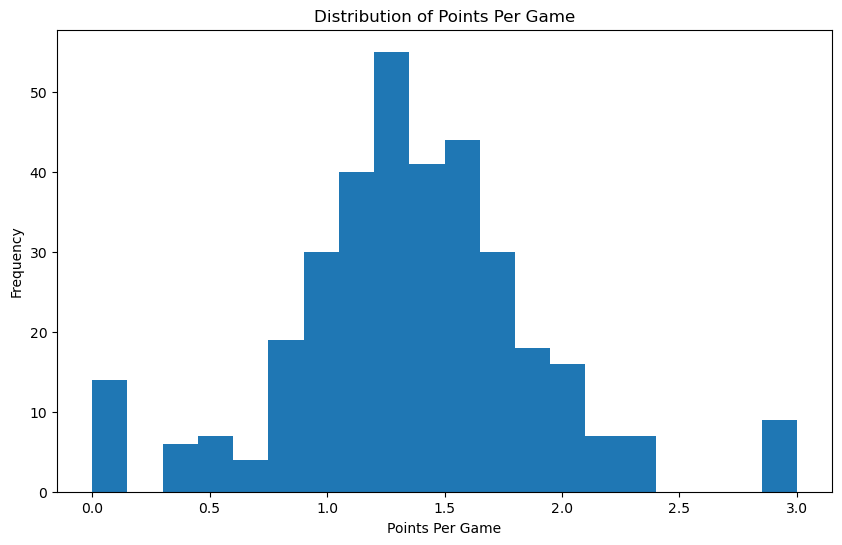

In [138]:
plt.figure(figsize=(10, 6))
plt.hist(team_season["ppg"], bins=20)
plt.xlabel("Points Per Game")
plt.ylabel("Frequency")
plt.title("Distribution of Points Per Game")
plt.show()

SCATTER PLOT PPG VS GOAL DIFFERENCE

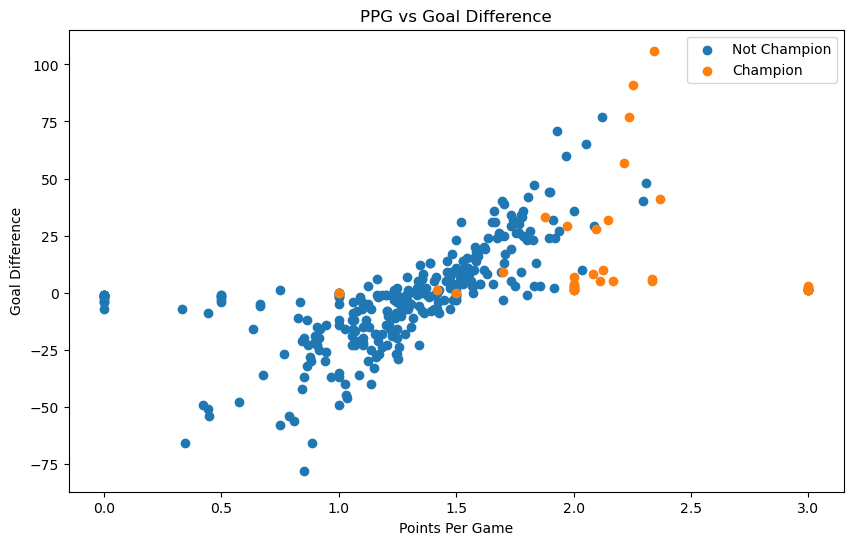

In [142]:
plt.figure(figsize=(10, 6))

champions = team_season[team_season["champion"] == 1]
non_champions = team_season[team_season["champion"] == 0]

plt.scatter(non_champions["ppg"], non_champions["gd"], label="Not Champion")
plt.scatter(champions["ppg"], champions["gd"], label="Champion")

plt.xlabel("Points Per Game")
plt.ylabel("Goal Difference")
plt.title("PPG vs Goal Difference")
plt.legend()
plt.show()

SCATTER PLOT WIN RATIO VS GOAL DIFFERENCE PER MATCH

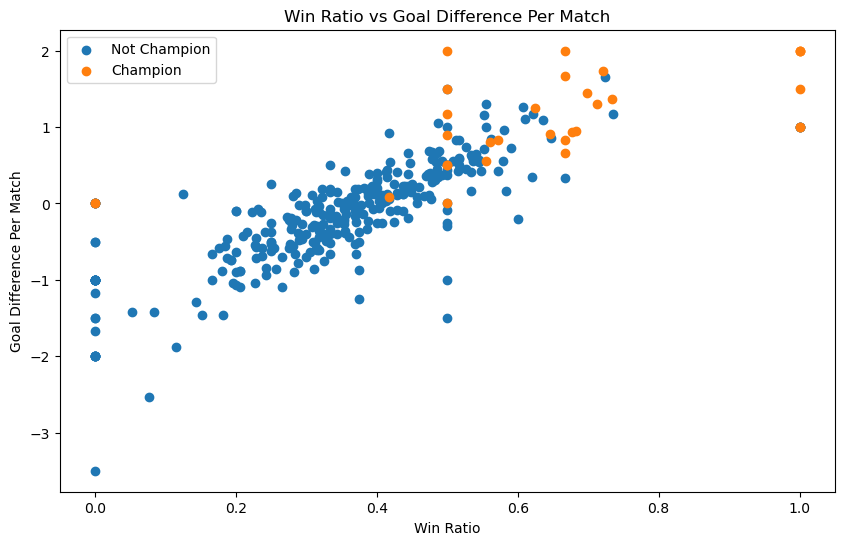

In [143]:
plt.figure(figsize=(10, 6))

plt.scatter(non_champions["win_ratio"], non_champions["gd_per_match"], label="Not Champion")
plt.scatter(champions["win_ratio"], champions["gd_per_match"], label="Champion")

plt.xlabel("Win Ratio")
plt.ylabel("Goal Difference Per Match")
plt.title("Win Ratio vs Goal Difference Per Match")
plt.legend()
plt.show()

LOGISTIC REGRESSION

In [144]:
log_coefficients = pd.Series(
    log_model.named_steps["classifier"].coef_[0],
    index=feature_cols
).sort_values()

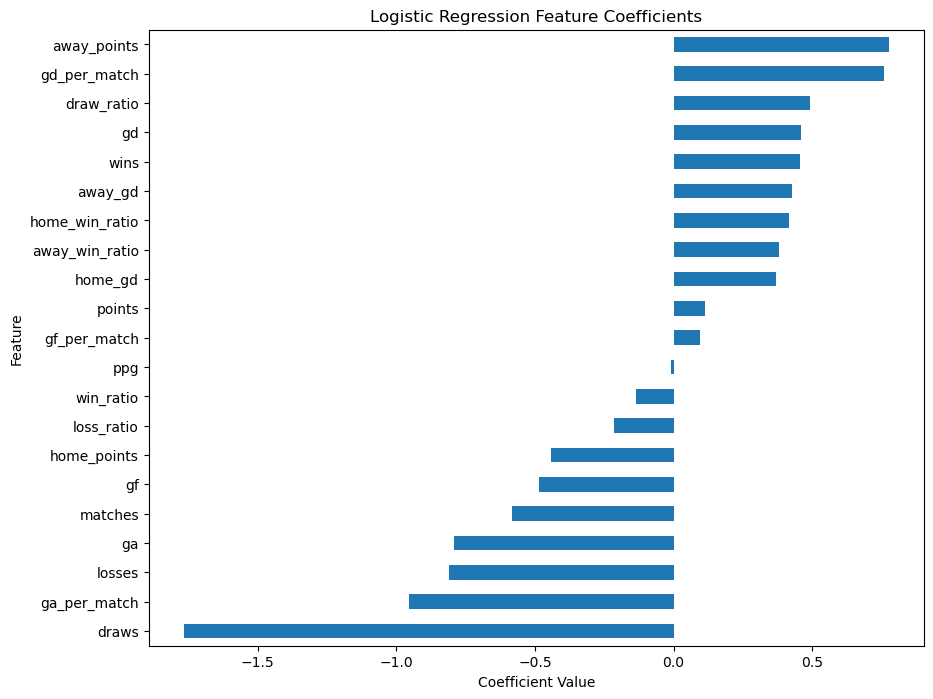

In [145]:
plt.figure(figsize=(10, 8))
log_coefficients.plot(kind="barh")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Coefficients")
plt.show()

ROC CURVE FOR LOGISTIC REGRESSION

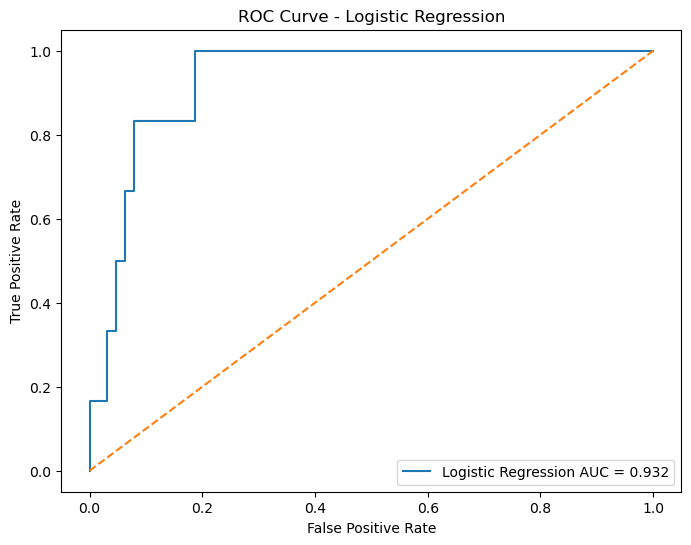

In [146]:
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
roc_auc_log = auc(fpr_log, tpr_log)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression AUC = {roc_auc_log:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

GRADIENT BOOSTING

In [147]:
gb_importance = pd.Series(
    gb_model.feature_importances_,
    index=feature_cols
).sort_values()

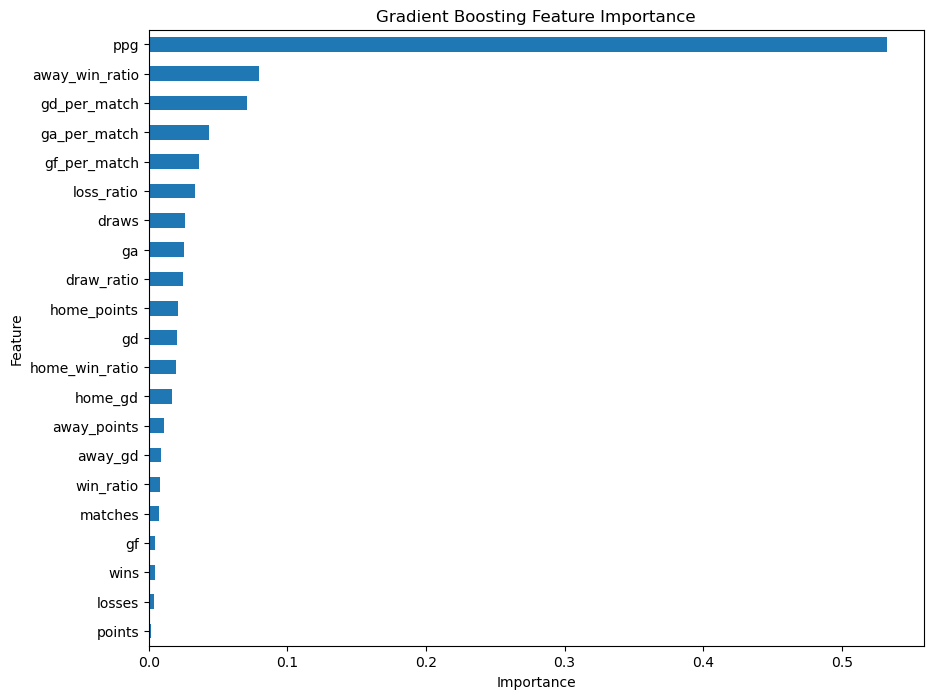

In [148]:
plt.figure(figsize=(10, 8))
gb_importance.plot(kind="barh")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")
plt.show()

ROC CURVE FOR GRADIENT BOOSTING

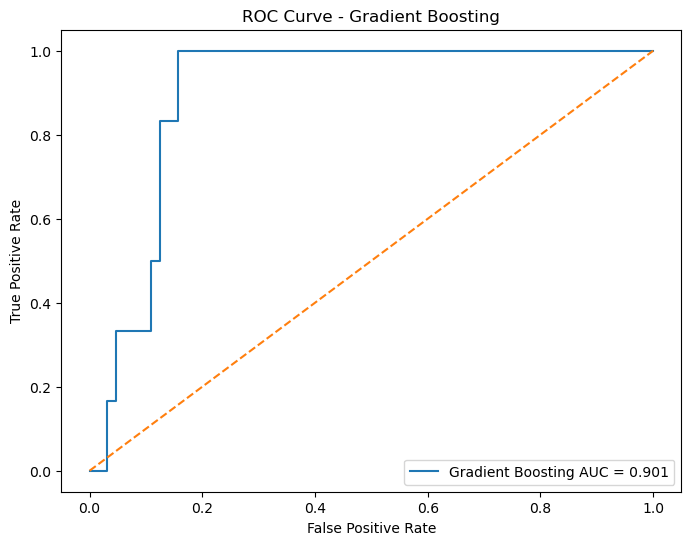

In [149]:
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probs)
roc_auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting AUC = {roc_auc_gb:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()


COMPARISON OF ROC CURVES

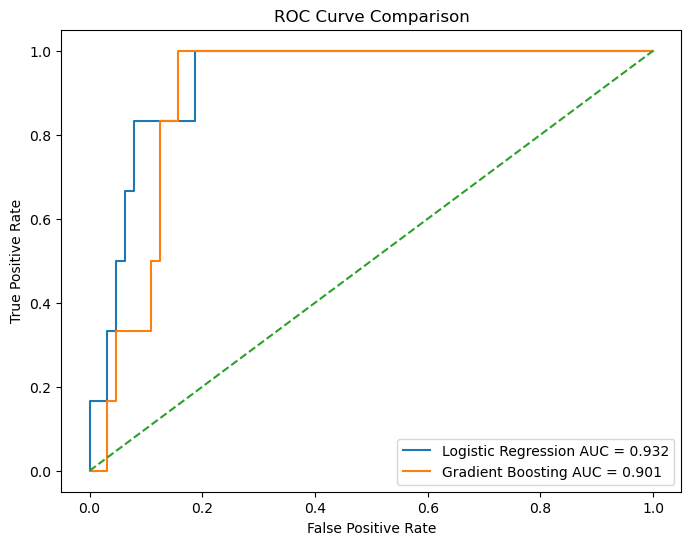

In [150]:
plt.figure(figsize=(8, 6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression AUC = {roc_auc_log:.3f}")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting AUC = {roc_auc_gb:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

TOP 10 TEAMS BY CHAMPION PROBABILITY

In [151]:
top_10 = prediction_leaderboard.head(10).copy()

CHAMPION PROBABILITY LEADERBOARD

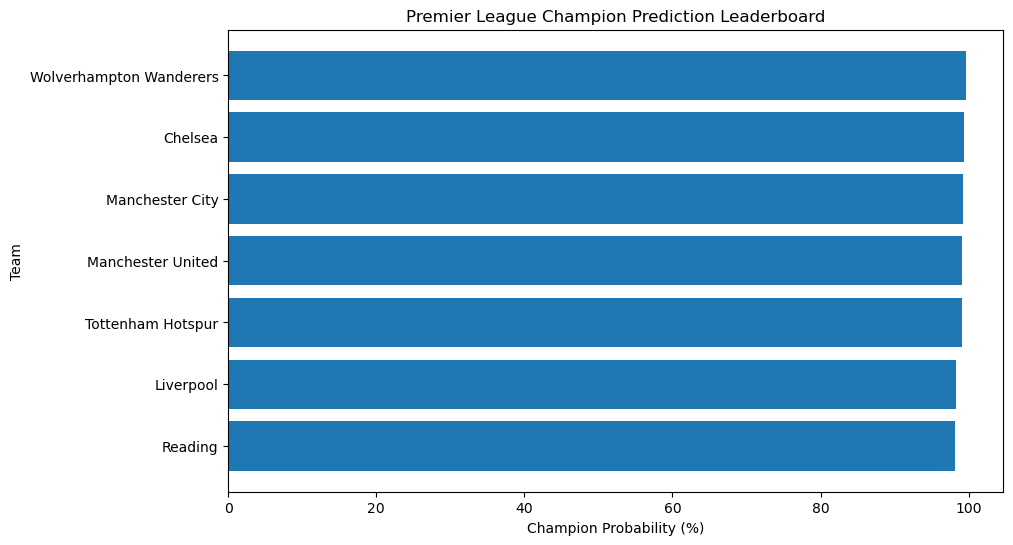

In [152]:
plt.figure(figsize=(10, 6))
plt.barh(top_10["team"], top_10["champion_probability"])
plt.xlabel("Champion Probability (%)")
plt.ylabel("Team")
plt.title("Premier League Champion Prediction Leaderboard")
plt.gca().invert_yaxis()
plt.show()

In [153]:
import joblib
joblib.dump(gb_model, "gb_model.pkl")

['gb_model.pkl']

In [154]:
team_season.to_csv("team_season_features.csv", index=False)